
📊 CALCULATING STRICT EVALUATION METRICS (U-NET)


Calculating Metrics: 100%|██████████| 5936/5936 [20:43<00:00,  4.77it/s]



🎯 DETECTION PERFORMANCE (mAP@[0.5:0.95])
Overall mAP@[0.5:0.95] : 0.4435

📈 PER-CLASS DETECTION (AUC & F1 @ 0.5 Thresh)
Short Sleeve Top     | AUC: 0.7824 | F1: 0.7699
Trousers             | AUC: 0.8046 | F1: 0.7872
Shorts               | AUC: 0.7331 | F1: 0.7083
Long Sleeve Top      | AUC: 0.7667 | F1: 0.5514
Skirt                | AUC: 0.7326 | F1: 0.6910

🖼️ ROC Curves saved to: /kaggle/working/unet_detection_roc_curves.png

🧩 SEGMENTATION PERFORMANCE (IoU & Dice)
Short Sleeve Top     | mIoU: 0.7239 | Dice: 0.8398
Trousers             | mIoU: 0.6917 | Dice: 0.8177
Shorts               | mIoU: 0.5574 | Dice: 0.7158
Long Sleeve Top      | mIoU: 0.5643 | Dice: 0.7215
Skirt                | mIoU: 0.6219 | Dice: 0.7669
--------------------------------------------------
🌟 MACRO-AVERAGED mIoU : 0.6318
🌟 MACRO-AVERAGED Dice : 0.7724


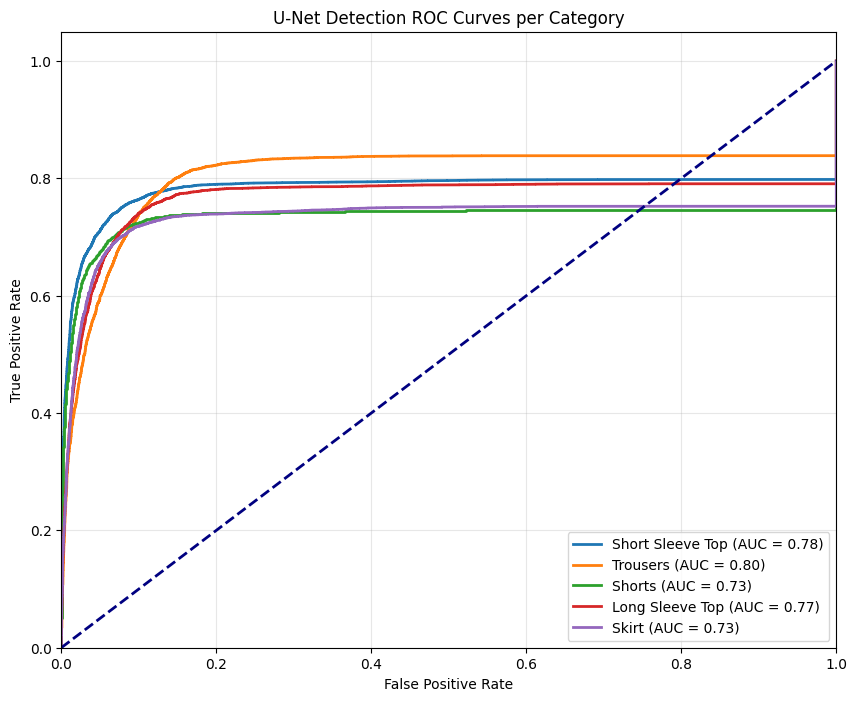

In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import torchvision.transforms.functional as TF
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou
from sklearn.metrics import roc_curve, auc, f1_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*50)
print("📊 CALCULATING STRICT EVALUATION METRICS (U-NET)")
print("="*50)

# ==========================================
# 1. SETUP PATHS & DEVICE
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VAL_DIR = "/kaggle/input/datasets/hrushi1998/vr-mini-proj-dataset/Trimmed_Dataset/trimmed_val_data"
VAL_JSON = os.path.join(VAL_DIR, "processed_val_data.json")

# Update this path to where you saved your U-Net weights!
BEST_MODEL_PATH = "/kaggle/input/datasets/hades1998/unet-finetuned/unet_resnet34_finetune.pth" 

NUM_CLASSES = 6
IMG_SIZE = 512

# ==========================================
# 2. DATASET (Exact same Ground Truth loader)
# ==========================================
class MasterJSONDataset(Dataset):
    def __init__(self, json_file, img_dir):
        self.img_dir = img_dir
        with open(json_file, 'r') as f:
            self.full_data = json.load(f)["data"]
        self.top_5_categories = [1, 8, 7, 2, 9] 
        self.label_map = {cat_id: idx + 1 for idx, cat_id in enumerate(self.top_5_categories)}

    def __len__(self): return len(self.full_data)

    def __getitem__(self, idx):
        item = self.full_data[idx]
        img_path = os.path.join(self.img_dir, item["image_path"])
        if not os.path.exists(img_path): return None
            
        img = Image.open(img_path).convert("RGB")
        width, height = img.size
        boxes, labels, masks = [], [], []
        
        categories = item.get("item_categories", [])
        bboxes = item.get("detection_bboxes", [])
        polygons = item.get("segmentation_polygons", [])
        
        for i in range(len(categories)):
            cat_id = categories[i]
            if cat_id in self.label_map:
                box = bboxes[i]
                if box[2] <= box[0] or box[3] <= box[1]: continue 
                
                labels.append(self.label_map[cat_id])
                boxes.append(box)
                
                mask = Image.new('L', (width, height), 0)
                draw = ImageDraw.Draw(mask)
                for poly in polygons[i]:
                    draw.polygon(poly, outline=1, fill=1)
                masks.append(np.array(mask))
                    
        if len(boxes) == 0: return None
            
        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "masks": torch.as_tensor(np.array(masks), dtype=torch.uint8),
            "image_id": torch.tensor([idx]),
            "area": torch.tensor([(b[2]-b[0])*(b[3]-b[1]) for b in boxes]),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64)
        }
        # Return the original PIL image to extract dimensions later
        return img, target

def custom_collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch: return ()
    return tuple(zip(*batch))

val_loader = DataLoader(MasterJSONDataset(VAL_JSON, VAL_DIR), batch_size=4, shuffle=False, num_workers=2, pin_memory=True, collate_fn=custom_collate)

# ==========================================
# 3. LOAD U-NET ARCHITECTURE & WEIGHTS
# ==========================================
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels // 2 + skip_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            diffY = skip.size()[2] - x.size()[2]
            diffX = skip.size()[3] - x.size()[3]
            x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
            x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class ResNet34UNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        resnet = models.resnet34(weights=None)
        self.encoder0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu) 
        self.maxpool = resnet.maxpool 
        self.encoder1 = resnet.layer1 
        self.encoder2 = resnet.layer2 
        self.encoder3 = resnet.layer3 
        self.encoder4 = resnet.layer4 
        self.decoder4 = DecoderBlock(512, 256, 256)
        self.decoder3 = DecoderBlock(256, 128, 128)
        self.decoder2 = DecoderBlock(128, 64, 64)
        self.decoder1 = DecoderBlock(64, 64, 64)
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)
    def forward(self, x):
        e0 = self.encoder0(x)       
        e1 = self.encoder1(self.maxpool(e0)) 
        e2 = self.encoder2(e1)      
        e3 = self.encoder3(e2)      
        d4 = self.decoder4(self.encoder4(e3), e3)
        d3 = self.decoder3(d4, e2)
        d2 = self.decoder2(d3, e1)
        out = self.final_conv(self.final_up(self.decoder1(d2, e0)))
        return out

model = ResNet34UNet(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.eval()

# ==========================================
# 4. EXACT METRICS CALCULATION (With CCA Bridge)
# ==========================================
box_metrics = MeanAveragePrecision(iou_type="bbox", class_metrics=True)

intersections = np.zeros(NUM_CLASSES)
unions = np.zeros(NUM_CLASSES)
target_areas = np.zeros(NUM_CLASSES)
pred_areas = np.zeros(NUM_CLASSES)

y_scores = {c: [] for c in range(1, NUM_CLASSES)}
y_true = {c: [] for c in range(1, NUM_CLASSES)}

SCORE_THRESH = 0.5 
IOU_THRESH = 0.5   

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Calculating Metrics"):
        if not batch: continue
        pil_images, targets = batch
        targets_gpu = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        outputs_formatted = []
        
        for pil_img, tgt in zip(pil_images, targets_gpu):
            orig_w, orig_h = pil_img.size
            
            # 1. Prepare image for U-Net
            img_resized = pil_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
            img_tensor = TF.to_tensor(img_resized)
            img_tensor = TF.normalize(img_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).unsqueeze(0).to(device)
            
            # 2. Get predictions and interpolate back to original size
            logits = model(img_tensor) # Shape: [1, Classes, 512, 512]
            logits_upscaled = F.interpolate(logits, size=(orig_h, orig_w), mode='bilinear', align_corners=False).squeeze(0)
            
            probs = F.softmax(logits_upscaled, dim=0)
            semantic_mask = torch.argmax(probs, dim=0).cpu().numpy()
            probs_np = probs.cpu().numpy()
            
            # 3. Connected Component Analysis (The Bridge)
            pred_boxes, pred_scores, pred_labels, pred_masks = [], [], [], []
            
            for c in range(1, NUM_CLASSES):
                class_mask = np.uint8(semantic_mask == c)
                if class_mask.sum() == 0: continue
                
                num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(class_mask, connectivity=8)
                
                for label_idx in range(1, num_labels): # Skip background
                    x, y, w, h, area = stats[label_idx]
                    
                    # Ignore tiny noise artifacts
                    if area < 50: continue 
                    
                    box = [x, y, x + w, y + h] # Convert to xyxy
                    component_pixels = (labels == label_idx)
                    
                    # Confidence Score = Mean probability of this class inside the component
                    score = probs_np[c][component_pixels].mean()
                    
                    pred_boxes.append(box)
                    pred_scores.append(score)
                    pred_labels.append(c)
                    pred_masks.append(component_pixels)
            
            # 4. Format for Evaluator
            out = {}
            if len(pred_boxes) == 0:
                out['boxes'] = torch.empty((0, 4), device=device)
                out['scores'] = torch.empty((0,), device=device)
                out['labels'] = torch.empty((0,), dtype=torch.int64, device=device)
                out['masks'] = torch.empty((0, orig_h, orig_w), dtype=torch.uint8, device=device)
            else:
                out['boxes'] = torch.tensor(pred_boxes, dtype=torch.float32, device=device)
                out['scores'] = torch.tensor(pred_scores, dtype=torch.float32, device=device)
                out['labels'] = torch.tensor(pred_labels, dtype=torch.int64, device=device)
                out['masks'] = torch.tensor(np.array(pred_masks), dtype=torch.uint8, device=device)
                
            outputs_formatted.append(out)

        # Update TorchMetrics MAP
        box_metrics.update(outputs_formatted, targets_gpu)

        # Custom loop for pixel mIoU/Dice and Detection ROC/F1
        for out, tgt in zip(outputs_formatted, targets_gpu):
            img_h, img_w = tgt['masks'].shape[1], tgt['masks'].shape[2]
            
            p_b, p_s, p_l, p_m = out['boxes'].cpu(), out['scores'].cpu(), out['labels'].cpu(), out['masks'].cpu().bool()
            t_b, t_l, t_m = tgt['boxes'].cpu(), tgt['labels'].cpu(), tgt['masks'].cpu().bool()
            
            # --- A. SEGMENTATION: Pixel-wise IoU & Dice ---
            for c in range(1, NUM_CLASSES):
                c_p_m = p_m[p_l == c]
                c_t_m = t_m[t_l == c]
                
                merged_p = c_p_m.any(dim=0).numpy() if len(c_p_m) > 0 else np.zeros((img_h, img_w), dtype=bool)
                merged_t = c_t_m.any(dim=0).numpy() if len(c_t_m) > 0 else np.zeros((img_h, img_w), dtype=bool)
                
                intersections[c] += np.logical_and(merged_p, merged_t).sum()
                unions[c] += np.logical_or(merged_p, merged_t).sum()
                pred_areas[c] += merged_p.sum()
                target_areas[c] += merged_t.sum()

            # --- B. DETECTION: Greedy matching for ROC & F1 ---
            for c in range(1, NUM_CLASSES):
                c_p_b, c_p_s, c_t_b = p_b[p_l == c], p_s[p_l == c], t_b[t_l == c]
                
                if len(c_t_b) == 0:
                    for s in c_p_s: 
                        y_scores[c].append(s.item())
                        y_true[c].append(0)
                    continue
                if len(c_p_b) == 0:
                    for _ in c_t_b: 
                        y_scores[c].append(0.0)
                        y_true[c].append(1)
                    continue
                
                ious = box_iou(c_p_b, c_t_b)
                matched_tgts = set()
                
                for i, s in enumerate(c_p_s):
                    max_iou, best_idx = (0, -1)
                    if ious.shape[1] > 0:
                        max_iou, best_idx = ious[i].max(dim=0)
                        max_iou, best_idx = max_iou.item(), best_idx.item()
                    
                    if max_iou >= IOU_THRESH and best_idx not in matched_tgts:
                        y_scores[c].append(s.item())
                        y_true[c].append(1) 
                        matched_tgts.add(best_idx)
                    else:
                        y_scores[c].append(s.item())
                        y_true[c].append(0) 
                        
                unmatched = len(c_t_b) - len(matched_tgts)
                for _ in range(unmatched):
                    y_scores[c].append(0.0)
                    y_true[c].append(1)

# ==========================================
# 5. PRINT OUTPUTS & SAVE CHARTS
# ==========================================
cat_names = {1: "Short Sleeve Top", 2: "Trousers", 3: "Shorts", 4: "Long Sleeve Top", 5: "Skirt"}

print("\n" + "="*50)
print("🎯 DETECTION PERFORMANCE (mAP@[0.5:0.95])")
print("="*50)
final_box = box_metrics.compute()
print(f"Overall mAP@[0.5:0.95] : {final_box['map'].item():.4f}")

print("\n" + "="*50)
print("📈 PER-CLASS DETECTION (AUC & F1 @ 0.5 Thresh)")
print("="*50)
plt.figure(figsize=(10, 8))
for c in range(1, NUM_CLASSES):
    if len(y_true[c]) == 0: continue
    y_t, y_s = np.array(y_true[c]), np.array(y_scores[c])
    fpr, tpr, _ = roc_curve(y_t, y_s)
    roc_auc = auc(fpr, tpr)
    y_pred_binary = (y_s >= SCORE_THRESH).astype(int)
    f1 = f1_score(y_t, y_pred_binary, zero_division=0)
    
    name = cat_names.get(c, f"Class {c}")
    print(f"{name:<20} | AUC: {roc_auc:.4f} | F1: {f1:.4f}")
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('U-Net Detection ROC Curves per Category')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig("/kaggle/working/unet_detection_roc_curves.png", dpi=300)
print("\n🖼️ ROC Curves saved to: /kaggle/working/unet_detection_roc_curves.png")

print("\n" + "="*50)
print("🧩 SEGMENTATION PERFORMANCE (IoU & Dice)")
print("="*50)
class_ious, class_dices = [], []
for c in range(1, NUM_CLASSES):
    iou = intersections[c] / (unions[c] + 1e-6)
    dice = (2 * intersections[c]) / (pred_areas[c] + target_areas[c] + 1e-6)
    class_ious.append(iou)
    class_dices.append(dice)
    name = cat_names.get(c, f"Class {c}")
    print(f"{name:<20} | mIoU: {iou:.4f} | Dice: {dice:.4f}")

print("-" * 50)
print(f"🌟 MACRO-AVERAGED mIoU : {np.mean(class_ious):.4f}")
print(f"🌟 MACRO-AVERAGED Dice : {np.mean(class_dices):.4f}")
print("="*50)